### Set Up Notebook

In [9]:
# Install necessary packages
%pip install numpy
%pip install pandas
%pip install pyspark

# Set up environment variables for Java, required by PySpark
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
os.environ["PATH"] = "/opt/homebrew/opt/openjdk@17/bin:" + os.environ["PATH"]

# Import necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)
from pyspark.sql import SparkSession
from pyspark.sql.functions import count
import time

# Clear Python's module cache to install fastf1
import sys
if 'typing_extensions' in sys.modules:
    del sys.modules['typing_extensions']

%pip install fastf1
import fastf1 as ff1


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Load Data for Single Race Session

In [2]:
time_start = time.time()

session_object = ff1.get_session(2025, "Britain", "R")
session_output = session_object.load()

time_end = time.time()
print(f"Duration of session load: {time_end - time_start} seconds")

req         WARNING 	DEFAULT CACHE ENABLED! (378.26 MB) /Users/anthony/Library/Caches/fastf1
events      WARNING 	Correcting user input 'Britain' to 'British Grand Prix'
core           INFO 	Loading data for British Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81

Duration of session load: 2.431252956390381 seconds


In [3]:
# Fetch telemetry data for all drivers
print(f"Fetching telemetry data for full driver list: {len(session_object.drivers)}")

telemetry_data = []
for driver in session_object.drivers:
    try:
        driver_data = session_object.laps.pick_drivers(driver).get_telemetry()
        if not driver_data.empty:
            driver_data["Driver"] = driver
            driver_data["SessionKey"] = (
                f"{session_object.event.EventName} {session_object.name}"
            )
            telemetry_data.append(driver_data)
    except Exception as e:
        print(f"Error while loading data for driver {driver}: {e}")

# Concatenate all driver telemetry into a single dataframe
try:
    combined_telemetry = pd.concat(telemetry_data, ignore_index=True)
    print(f"Records in combined telemetry data: {len(combined_telemetry)}")
    print(f"Preview of combined telemetry data: {combined_telemetry.head()}")
except Exception as e:
    print(f"Error while concatenating driver telemetry data: {e}.")

Fetching telemetry data for full driver list: 20
Records in combined telemetry data: 706923
Preview of combined telemetry data:                      Date            SessionTime DriverAhead  \
0 2025-07-06 14:03:49.616 0 days 00:56:09.003000               
1 2025-07-06 14:03:49.726 0 days 00:56:09.113000               
2 2025-07-06 14:03:49.813 0 days 00:56:09.200000               
3 2025-07-06 14:03:49.926 0 days 00:56:09.313000               
4 2025-07-06 14:03:50.053 0 days 00:56:09.440000               

   DistanceToDriverAhead                   Time          RPM  Speed  nGear  \
0                    0.0        0 days 00:00:00  9451.855018    0.0      2   
1                    0.0 0 days 00:00:00.110000  9483.205055    0.0      2   
2                    0.0 0 days 00:00:00.197000  9508.000000    0.0      2   
3                    0.0 0 days 00:00:00.310000  9112.499328    0.0      2   
4                    0.0 0 days 00:00:00.437000  8668.000000    0.0      2   

   Throttle  Brake

### Count record counts by unique values, to assess potential skew of columns

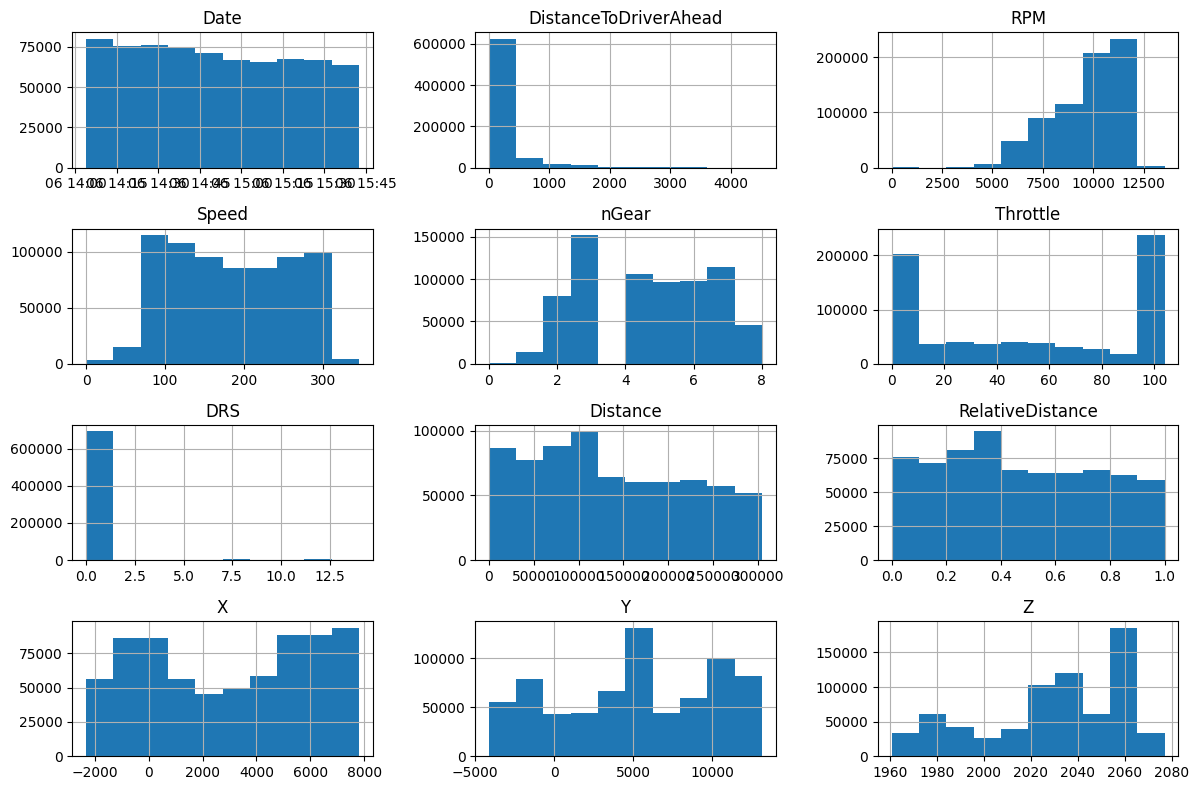

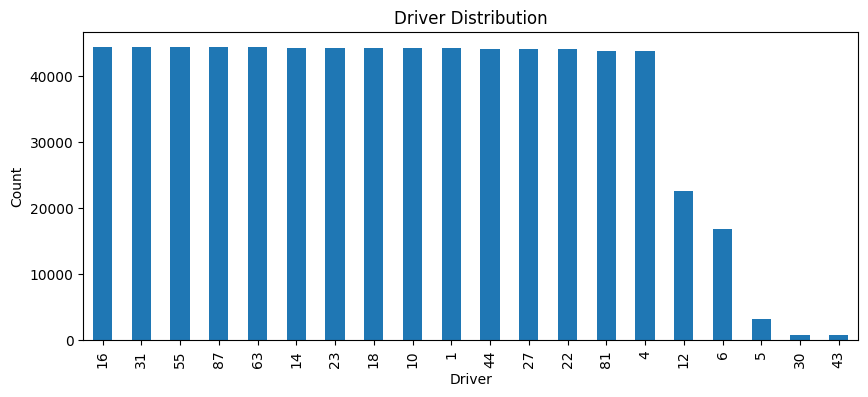

In [ ]:
# For numeric columns: histograms
combined_telemetry.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# For categorical columns (e.g., 'Driver'):
combined_telemetry["Driver"].value_counts().plot(
    kind="bar", figsize=(10, 4), title="Driver Distribution"
)
plt.ylabel("Count")
plt.show()

Date appears to have the most even distribution. Leverage for partitioning.

### Assess Impacts of Spark Configuration Settings

In [ ]:
def create_spark_session(cores):
    return (
        SparkSession.builder.appName("partitioning_cores")
        .master(f"local[{cores}]")
        .config("spark.driver.memory", "6g")
        .getOrCreate()
    )

In [ ]:
# Test different core counts - 4, 6, and * (8)
core_count = "*"

spark = create_spark_session(core_count)
spark.sparkContext.setLogLevel("WARN")
spark_df = spark.createDataFrame(combined_telemetry)

# Perform hash partitioning
start_time = time.time()
partitioned_df = spark_df.repartition("Driver")
partitioned_df.write.mode("overwrite").parquet(
    f"f1_telemetry_partitioned_{core_count}.parquet"
)
execution_time = time.time() - start_time

# Print results
print(f"Master: local[{core_count}]")
print(f"Number of partitions: {partitioned_df.rdd.getNumPartitions()}")
print(f"Execution time: {execution_time:.2f} seconds")

input(f"Press Enter to stop Spark session...")
spark.stop()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/07/09 18:03:42 WARN Utils: Your hostname, Anthonys-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.6 instead (on interface en0)
25/07/09 18:03:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/09 18:03:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/07/09 18:04:15 WARN TaskSetManager: Stage 0 contains a task of very large size (11003 KiB). The maximum recommended task size is 1000 KiB.
25/07/09 18:04:18 WARN TaskSetManager: Stage 3 contains a task of very large size (11003 KiB). The maximum recommended task size is 1000 KiB.


Master: local[*]
Number of partitions: 11
Execution time: 3.66 seconds


### Core Count Usage
- 4 cores:
    - Partitions: 5
    - Execution Time: 3.49s
    - Python % CPU: 99
    - Java % CPU: 241
- 6 cores:
    - Partitions: 8
    - Execution Time: 1.26 seconds
    - Python % CPU: 100
    - Java % CPU: 109
- 8 cores:
    - Partitions: 11
    - Execution Time: 1.27 seconds
    - Python % CPU: 100
    - Java % CPU: 104

Analysis: Execution time considerably improved moving from 4 to 6 cores but not to the full 8, indicating no benefit to consuming additional system resources. Select 6 for implementation.

### Experiment with Repartitioning

In [ ]:
spark_repartitioning = (
    SparkSession.builder.appName("partitioning_repartitioning")
    .master(f"local[6]")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "6")
    .config("spark.ui.port", "4050")
    .getOrCreate()
)

repartition_df = spark_repartitioning.createDataFrame(combined_telemetry)

# Check partition sizes before repartition
initial_sizes = repartition_df.rdd.glom().map(len).collect()
print(f"Initial partition sizes (rows): {initial_sizes}")

# Perform partitioning and aggregation task
start_time = time.time()
partitioned_df = repartition_df.repartition(6, "SessionTime").persist()
result = partitioned_df.groupBy("Driver").agg(count("Speed").alias("SpeedCount"))
result.write.mode("overwrite").parquet("f1_telemetry_partitioned_local6")
execution_time = time.time() - start_time

# Check partition sizes after repartition
partition_sizes = partitioned_df.rdd.glom().map(len).collect()
print(f"Partition sizes after repartition (rows): {partition_sizes}")

# Print results
print(f"Master: local[6]")
print(f"Requested partitions: 6")
print(f"Actual partitions: {partitioned_df.rdd.getNumPartitions()}")
print(f"Execution time: {execution_time:.2f} seconds")

input(f"Press Enter to stop Spark session...")
spark_repartitioning.stop()

25/07/11 16:25:32 WARN TaskSetManager: Stage 0 contains a task of very large size (14709 KiB). The maximum recommended task size is 1000 KiB.
25/07/11 16:26:00 WARN TaskSetManager: Stage 1 contains a task of very large size (14709 KiB). The maximum recommended task size is 1000 KiB.


Initial partition sizes (rows): [117760, 117760, 117760, 117760, 117760, 118123]
Physical plan:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[Driver#1568], functions=[count(Speed#1556)])
   +- Exchange hashpartitioning(Driver#1568, 6), ENSURE_REQUIREMENTS, [plan_id=585]
      +- HashAggregate(keys=[Driver#1568], functions=[partial_count(Speed#1556)])
         +- InMemoryTableScan [Speed#1556, Driver#1568]
               +- InMemoryRelation [Date#1550, SessionTime#1551, DriverAhead#1552, DistanceToDriverAhead#1553, Time#1554, RPM#1555, Speed#1556, nGear#1557L, Throttle#1558, Brake#1559, DRS#1560L, Source#1561, Distance#1562, RelativeDistance#1563, Status#1564, X#1565, Y#1566, Z#1567, Driver#1568, SessionKey#1569], StorageLevel(disk, memory, deserialized, 1 replicas)
                     +- AdaptiveSparkPlan isFinalPlan=false
                        +- Exchange hashpartitioning(SessionTime#1551, 6), REPARTITION_BY_NUM, [plan_id=572]
                      

Partition sizes after repartition (rows): [117730, 119855, 118375, 115324, 118633, 117006]
Master: local[6]
Requested partitions: 6
Actual partitions: 6
Execution time: 0.83 seconds


Python % CPU: 99.9% for 6 CPU's